<a href="https://colab.research.google.com/github/FurkanAlpGurakan/AYM-Karar-Tahmini-NLP/blob/main/RoBERTa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Başlangıç Ayarları

Bu bölümde, veri işleme, modelleme ve görselleştirme için gerekli kütüphaneler yüklenir.
Google Colab üzerinde çalışıldığı için Google Drive bağlantısı kurulmuş ve eğitim verisinin bulunduğu dosya yolu tanımlanmıştır.

In [ ]:
# ==============================================================================
# 1. ORTAM KURULUMU VE KÜTÜPHANELER
# ==============================================================================

!pip install transformers datasets accelerate -U -q
!pip install scikit-learn pandas openpyxl -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 511.6/511.6 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 20.2 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
import os
from google.colab import drive

# DRIVE BAĞLANTISI
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# AYARLAR
VERI_YOLU = "/content/drive/MyDrive/Dava_Sonuc_Tahmin/Final_Veriseti_Egitim.xlsx"
SAVE_PATH = "/content/drive/MyDrive/Dava_Sonuc_Tahmin/AYM_Roberta_Model"
MODEL_NAME = "dbmdz/bert-base-turkish-cased"
MAX_LENGTH = 512
N_FOLDS = 5 # 5 Katlı Doğrulama

# Cihaz belirleme
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Kullanılan Cihaz: {device}")
print("==========================================================")

Mounted at /content/drive
✅ Kullanılan Cihaz: cuda


RoBERTa modelinin 512 token girdi sınırını aşmamak için "Head + Tail" stratejisi uygulanmıştır.
Hukuki metinlerde olayın özü girişte, karar ise sonda olduğu için;
metnin başından 60, sonundan 240 kelime alınıp birleştirilmiştir.

In [ ]:
# ==============================================================================
# 2. VERİ HAZIRLIĞI VE ÖN İŞLEME (HEAD + TAIL)
# ==============================================================================
print(f"Dosya okunuyor: {VERI_YOLU}")

try:
    df = pd.read_excel(VERI_YOLU)
    df = df.dropna(subset=["Metin", "Etiket"])
except Exception as e:
    print(f"HATA: Dosya okunamadı! Hata: {e}")
    exit()

# Temizlik
df["Etiket"] = df["Etiket"].astype(str).str.strip()
unique_labels = sorted(df["Etiket"].unique())
label_map = {label: i for i, label in enumerate(unique_labels)}
df['label_id'] = df["Etiket"].map(label_map)

print(f"Etiketler: {unique_labels}")
print(f"Harita: {label_map}")

# --- STRATEJİ: BAŞ + SON BİRLEŞTİRME ---
def bas_ve_son_birlestir(metin):
    kelimeler = str(metin).split() # Boşluklardan böl

    # Toplam 300 Kelime (yaklaşık olarak 500-550 token eder, tam sınırda)
    bas_limit = 60
    son_limit = 240

    # Eğer metin zaten kısaysa olduğu gibi bırak
    if len(kelimeler) <= (bas_limit + son_limit):
        return " ".join(kelimeler)

    # Uzunsa Baş ve Sonu alıp birleştir
    bas_kisim = kelimeler[:bas_limit]
    son_kisim = kelimeler[-son_limit:]

    # Araya ayırıcı koy
    yeni_metin = " ".join(bas_kisim) + " ... " + " ".join(son_kisim)
    return yeni_metin

print(" Metinler işleniyor (Giriş + Hüküm birleştiriliyor)...")
df['Metin_Islemli'] = df['Metin'].apply(bas_ve_son_birlestir)

📂 Dosya okunuyor: /content/drive/MyDrive/Dava_Sonuc_Tahmin/Final_Veriseti_Egitim.xlsx
✅ Etiketler: ['İhlal_Var', 'İhlal_Yok', 'Kabul_Edilemez']
✅ Harita: {'İhlal_Var': 0, 'İhlal_Yok': 1, 'Kabul_Edilemez': 2}
✂️ Metinler işleniyor (Giriş + Hüküm birleştiriliyor)...


Bu bölümde, tokenize edilmiş verileri PyTorch modelinin işleyebileceği tensör formatına dönüştüren özel Dataset sınıfı tanımlanmıştır. Ayrıca, modelin performansını çok yönlü analiz edebilmek için sınıf dengesizliğini de gözeten ağırlıklı (weighted) F1-Score, Accuracy, Precision ve Recall değerlerini hesaplayan değerlendirme fonksiyonu oluşturulmuştur.

In [ ]:
# ==============================================================================
# 3. SINIF VE METRİK TANIMLAMALARI
# ==============================================================================
class AYMDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item

    def __len__(self):
        return len(self.labels)

def compute_metrics(p):
    preds = np.argmax(p.predictions, axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        p.label_ids, preds, average='weighted', zero_division=0
    )
    acc = accuracy_score(p.label_ids, preds)
    return {'accuracy': acc, 'f1': f1, 'precision': precision, 'recall': recall}

Burası asıl eğitimin yapıldığı kısımdır. Modelin genelleme başarısını ölçmek ve veriye dayalı yanlılığı (bias) önlemek amacıyla Stratified 5-Fold Cross-Validation yöntemi uygulanmıştır. Her döngüde verisetinin farklı bir parçası test için ayrılmış, disk dolumunu önleyen optimizasyon ayarlarıyla eğitim gerçekleştirilmiş ve tüm turlar sonunda en yüksek F1 skoruna sahip model nihai ağırlıklar olarak kaydedilmiştir.

In [ ]:
# ==============================================================================
# 4. CROSS VALIDATION DÖNGÜSÜ (EĞİTİM)
# ==============================================================================
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

X = df['Metin_Islemli'].values
y = df['label_id'].values

fold_accs = []
fold_f1s = []
best_f1 = 0.0

print(f"\n {N_FOLDS}-Fold Cross Validation Başlıyor... (Bu işlem biraz sürebilir)")
print("=" * 60)

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f"\n FOLD {fold + 1} / {N_FOLDS} Eğitiliyor...")

    # Veriyi Böl
    train_texts, val_texts = X[train_idx], X[val_idx]
    train_labels, val_labels = y[train_idx], y[val_idx]

    # Tokenize Et
    train_encodings = tokenizer(list(train_texts), truncation=True, padding=True, max_length=MAX_LENGTH, return_tensors="pt")
    val_encodings = tokenizer(list(val_texts), truncation=True, padding=True, max_length=MAX_LENGTH, return_tensors="pt")

    # Dataset Oluştur
    train_dataset = AYMDataset(train_encodings, torch.tensor(train_labels))
    val_dataset = AYMDataset(val_encodings, torch.tensor(val_labels))

    # Modeli Sıfırla
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3).to(device)

    # ---  KRİTİK GÜNCELLEME BURADA  ---
    training_args = TrainingArguments(
        output_dir=f'./results/fold-{fold+1}',
        num_train_epochs=4,
        learning_rate=3e-5,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        warmup_steps=100,
        weight_decay=0.01,
        logging_steps=50,

        # DİSK DOSTU & GRAFİK KURTARICI AYARLAR:
        eval_strategy="epoch",       # Her epoch'ta test et
        save_strategy="epoch",       # Her epoch'ta kaydet (JSON oluşsun diye)
        save_total_limit=1,          # DİKKAT: Sadece en son 1 taneyi tut, eskileri sil çünkü disk dolma problemi var
        load_best_model_at_end=True, # En iyi modeli geri yükle
        metric_for_best_model="f1",  # F1 skoruna göre en iyisini seç

        report_to='none'
    )
    # --------------------------------------

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics
    )

    # Eğit
    trainer.train()

    # Değerlendir
    eval_result = trainer.evaluate()
    acc = eval_result['eval_accuracy']
    f1 = eval_result['eval_f1']

    fold_accs.append(acc)
    fold_f1s.append(f1)

    print(f"FOLD {fold + 1} Sonucu -> Accuracy: {acc:.4f} | F1: {f1:.4f}")

    # En İyi Modeli Kaydet (Arayüz için)
    # Burası Fold içindeki en iyiyi değil, TÜM foldlar arasındaki en iyiyi 'AYM_Roberta_Model' klasörüne yazar.
    if f1 > best_f1:
        best_f1 = f1
        print(f"YENİ REKOR! En iyi model güncelleniyor (F1: {f1:.4f})...")
        trainer.save_model(SAVE_PATH)
        tokenizer.save_pretrained(SAVE_PATH)

    # Bellek Temizliği
    del model, trainer, train_encodings, val_encodings
    torch.cuda.empty_cache()
    print("-" * 40)


🚀 5-Fold Cross Validation Başlıyor... (Bu işlem biraz sürebilir)

🔄 FOLD 1 / 5 Eğitiliyor...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dbmdz/bert-base-turkish-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.888900,0.684935,0.725000,0.721475,0.743897,0.725000
2,0.434300,0.447901,0.838889,0.840100,0.851855,0.838889
3,0.361700,0.416002,0.877778,0.878449,0.882387,0.877778
4,0.225800,0.518513,0.863889,0.864318,0.865469,0.863889


✅ FOLD 1 Sonucu -> Accuracy: 0.8778 | F1: 0.8784
🏆 YENİ REKOR! En iyi model güncelleniyor (F1: 0.8784)...
----------------------------------------

🔄 FOLD 2 / 5 Eğitiliyor...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dbmdz/bert-base-turkish-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.961600,0.754529,0.708333,0.702161,0.748223,0.708333
2,0.557000,0.493773,0.819444,0.820741,0.843024,0.819444
3,0.334400,0.486517,0.855556,0.856012,0.859659,0.855556
4,0.205100,0.567769,0.844444,0.844496,0.847188,0.844444


✅ FOLD 4 Sonucu -> Accuracy: 0.8556 | F1: 0.8560
----------------------------------------

🔄 FOLD 5 / 5 Eğitiliyor...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dbmdz/bert-base-turkish-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.920400,0.817427,0.611111,0.563039,0.662614,0.611111
2,0.498800,0.567683,0.800000,0.798354,0.822174,0.800000
3,0.346400,0.507647,0.841667,0.841869,0.843066,0.841667
4,0.158500,0.604160,0.847222,0.847131,0.848474,0.847222


✅ FOLD 5 Sonucu -> Accuracy: 0.8472 | F1: 0.8471
----------------------------------------


Burada sonuç raporları yazdırılır.

In [ ]:
# ==============================================================================
# 5. FİNAL SONUÇ RAPORU
# ==============================================================================
print("\n" + "="*60)
print(f"{N_FOLDS}-FOLD CROSS VALIDATION GENEL SONUÇLARI")
print("="*60)
print(f"Fold Skorları (Accuracy): {fold_accs}")
print(f"ORTALAMA ACCURACY: {np.mean(fold_accs):.4f}")
print(f"ORTALAMA F1 SCORE: {np.mean(fold_f1s):.4f}")
print(f"Standard Sapma: {np.std(fold_accs):.4f}")
print(f"En başarılı model şuraya kaydedildi: {SAVE_PATH}")
print("="*60)


📊 5-FOLD CROSS VALIDATION GENEL SONUÇLARI
Fold Skorları (Accuracy): [0.8777777777777778, 0.8555555555555555, 0.8555555555555555, 0.8555555555555555, 0.8472222222222222]
🏆 ORTALAMA ACCURACY: 0.8583
🏆 ORTALAMA F1 SCORE: 0.8586
Standard Sapma: 0.0102
🚀 En başarılı model şuraya kaydedildi: /content/drive/MyDrive/Dava_Sonuc_Tahmin/AYM_Roberta_Model


Burada en yüksek doğruluk skoruna sahip olan yani kaydedilen modelin grafikleri ve genel özet skorları yazdırılır. Eğitim yapıldıktan sonra bellek dolmasın diye silinen veriler yani değişkenler olduğundan tekrar o değişkenlere atamalar yapılır (eğitim verisi seçimi ve head+tail ayrımı) ve daha sonra tekrar model test edilir (grafikleri yazdırmak için gerekli değişkenler).

🕵️‍♂️ '/content/drive/MyDrive/Dava_Sonuc_Tahmin/Sonuclar' içinde log dosyası aranıyor...
✅ Log dosyası bulundu: /content/drive/MyDrive/Dava_Sonuc_Tahmin/Sonuclar/checkpoint-900/trainer_state.json


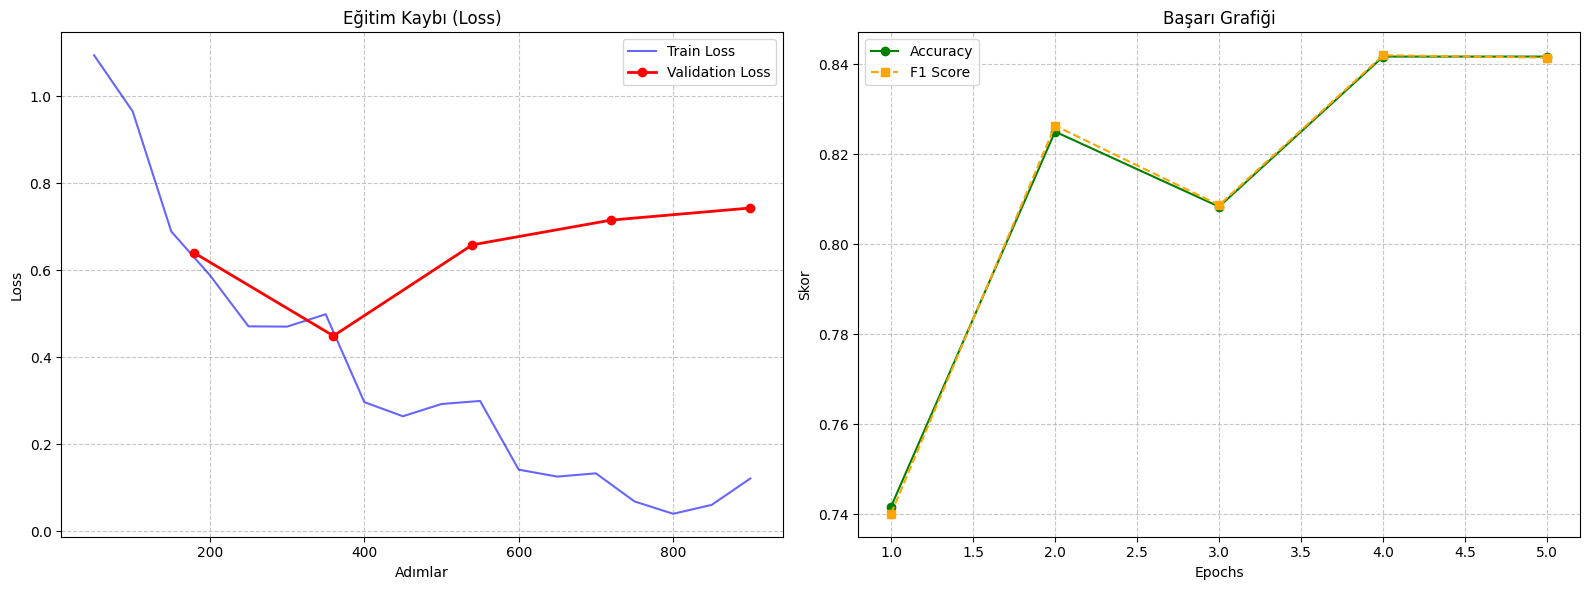


🤖 Model Yükleniyor ve %20'lik Test Seti Ayrılıyor...
✂️ Veri seti bölünüyor... (Test Size: 0.20)
📊 Toplam Veri: 1800 -> Test Edilecek Veri: 360


Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


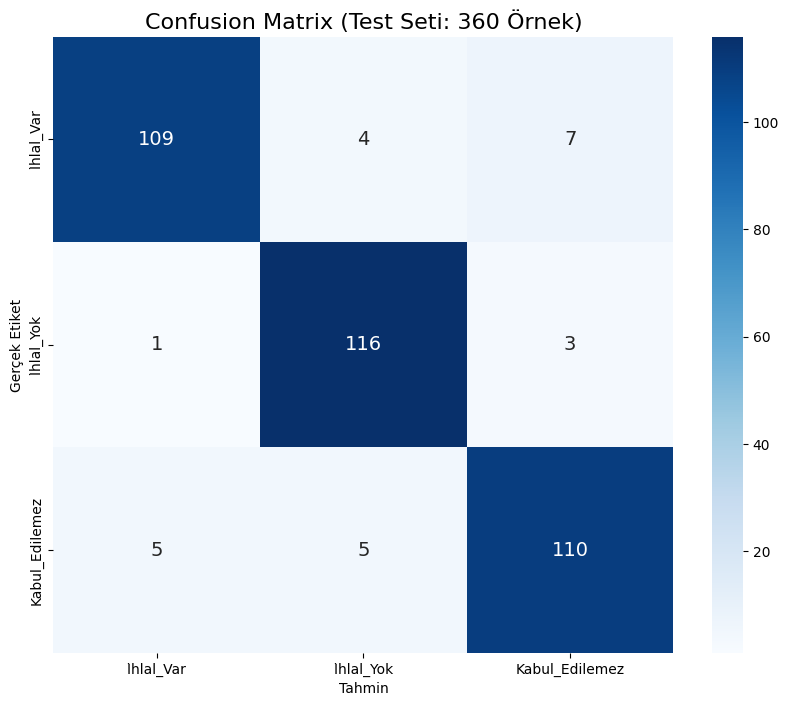


📄 DETAYLI PERFORMANS RAPORU (SADECE TEST SETİ)
                precision    recall  f1-score   support

    İhlal_Var     0.9478    0.9083    0.9277       120
    İhlal_Yok     0.9280    0.9667    0.9469       120
Kabul_Edilemez     0.9167    0.9167    0.9167       120

      accuracy                         0.9306       360
     macro avg     0.9308    0.9306    0.9304       360
  weighted avg     0.9308    0.9306    0.9304       360



In [ ]:
# ==============================================================================
# 📊 FİNAL GÖRSELLEŞTİRME: LOSS GRAFİĞİ + %20 TEST (CONFUSION MATRIX)
# ==============================================================================

import json
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split  # <--- EKLENDİ
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer
from torch.utils.data import Dataset
from google.colab import drive
os.environ["WANDB_DISABLED"] = "true"

# 1. BAĞLANTI
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# --- AYARLAR ---
MODEL_YOLU = "/content/drive/MyDrive/Dava_Sonuc_Tahmin/AYM_Roberta_Model"
VERI_YOLU = "/content/drive/MyDrive/Dava_Sonuc_Tahmin/Final_Veriseti_Egitim.xlsx"
ARAMA_YAPILACAK_ANA_KLASOR = "/content/drive/MyDrive/Dava_Sonuc_Tahmin/Sonuclar"
# -------------------------------------------------------

# ==============================================================================
# A) EĞİTİM GEÇMİŞİNİ BUL VE ÇİZ (LOSS & ACCURACY)
# ==============================================================================
print(f"🕵️‍♂️ '{ARAMA_YAPILACAK_ANA_KLASOR}' içinde log dosyası aranıyor...")

bulunan_loglar = glob.glob(f"{ARAMA_YAPILACAK_ANA_KLASOR}/**/trainer_state.json", recursive=True)

if not bulunan_loglar:
    print("❌ Log dosyası bulunamadı! Loss grafiği çizilemiyor.")
else:
    target_json = max(bulunan_loglar, key=os.path.getmtime)
    print(f"✅ Log dosyası bulundu: {target_json}")

    try:
        with open(target_json, 'r') as f:
            data = json.load(f)

        history = data['log_history']
        train_loss, eval_loss, eval_acc, eval_f1 = [], [], [], []
        steps_train, epochs_eval = [], []

        for log in history:
            if 'loss' in log:
                train_loss.append(log['loss'])
                steps_train.append(log['step'])
            if 'eval_loss' in log:
                eval_loss.append(log['eval_loss'])
                eval_acc.append(log.get('eval_accuracy', log.get('eval_acc', 0)))
                eval_f1.append(log.get('eval_f1', 0))
                epochs_eval.append(log['epoch'])

        # GRAFİK ÇİZİMİ
        plt.figure(figsize=(16, 6))

        # 1. Loss
        plt.subplot(1, 2, 1)
        if train_loss: plt.plot(steps_train, train_loss, label='Train Loss', color='blue', alpha=0.6)
        if eval_loss:
            if steps_train and epochs_eval:
                 eval_steps = [steps_train[-1] * (e / epochs_eval[-1]) for e in epochs_eval]
            else:
                 eval_steps = list(range(len(eval_loss)))
            plt.plot(eval_steps, eval_loss, label='Validation Loss', color='red', marker='o', linewidth=2)
        plt.title('Eğitim Kaybı (Loss)')
        plt.xlabel('Adımlar'); plt.ylabel('Loss')
        plt.legend(); plt.grid(True, linestyle='--', alpha=0.7)

        # 2. Accuracy
        plt.subplot(1, 2, 2)
        if eval_acc:
            plt.plot(epochs_eval, eval_acc, label='Accuracy', marker='o', color='green')
            plt.plot(epochs_eval, eval_f1, label='F1 Score', marker='s', color='orange', linestyle='--')
        plt.title('Başarı Grafiği')
        plt.xlabel('Epochs'); plt.ylabel('Skor')
        plt.legend(); plt.grid(True, linestyle='--', alpha=0.7)

        plt.tight_layout(); plt.show()

    except Exception as e:
        print(f"⚠️ Grafik hatası: {e}")

# ==============================================================================
# B) CONFUSION MATRIX (SADECE %20 TEST SETİ İLE)
# ==============================================================================
print("\n🤖 Model Yükleniyor ve %20'lik Test Seti Ayrılıyor...")

try:
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_YOLU)
    tokenizer = AutoTokenizer.from_pretrained(MODEL_YOLU)
except:
    print(f"❌ Model yüklenemedi! Yol: {MODEL_YOLU}")
    exit()

# 1. Veri Hazırla
df = pd.read_excel(VERI_YOLU).dropna(subset=["Metin", "Etiket"])
df["Etiket"] = df["Etiket"].astype(str).str.strip()
labels = sorted(df["Etiket"].unique())
label_map = {l: i for i, l in enumerate(labels)}

# 2. Ön İşleme
def process(t):
    w = str(t).split()
    return " ".join(w) if len(w)<=300 else " ".join(w[:60]) + " ... " + " ".join(w[-240:])
df['text'] = df['Metin'].apply(process)

# 3. VERİYİ BÖL (%80 Eğitim - %20 Test)
# stratify=df['Etiket'] sayesinde her sınıftan eşit oranda örnek alır.
print("✂️ Veri seti bölünüyor... (Test Size: 0.20)")
_, X_test, _, y_test = train_test_split(
    df['text'],
    df['Etiket'].map(label_map),
    test_size=0.20,
    random_state=42,
    stratify=df['Etiket']
)

print(f"📊 Toplam Veri: {len(df)} -> Test Edilecek Veri: {len(X_test)}")

# 4. Dataset
class TD(Dataset):
    def __init__(self, t, l, tok):
        self.e = tok(list(t), truncation=True, padding=True, max_length=512, return_tensors="pt")
        self.l = torch.tensor(list(l))
    def __getitem__(self, i):
        item = {k: v[i] for k, v in self.e.items()}
        item['labels'] = self.l[i]
        return item
    def __len__(self): return len(self.l)

# 5. Tahmin
test_dataset = TD(X_test, y_test, tokenizer)
trainer = Trainer(model=model)
preds = trainer.predict(test_dataset)
y_pred = np.argmax(preds.predictions, axis=1)

# 6. Matris Çiz
cm = confusion_matrix(preds.label_ids, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, annot_kws={"size": 14})
plt.title(f'Confusion Matrix (Test Seti: {len(X_test)} Örnek)', fontsize=16)
plt.ylabel('Gerçek Etiket'); plt.xlabel('Tahmin')
plt.show()

# 7. Rapor
print("\n" + "="*60)
print("📄 DETAYLI PERFORMANS RAPORU (SADECE TEST SETİ)")
print("="*60)
print(classification_report(preds.label_ids, y_pred, target_names=labels, digits=4))

Burada arayüz tanımlama yapılıyor. Gradio arayüzü ile modelin herkes tarafından rahatça test edilebilmesi için gradio kütüphanesinden yararlanıldı. Kullanıcı tarafından yüklenen verinin işlemesi de aynı şekilde bu kısımda yapılır.

In [ ]:
# 1. OTOMATİK KURULUM
import os
import sys

def install_libs():
    libs = ["python-docx", "gradio", "transformers", "torch", "pandas"]
    print("Gerekli kütüphaneler kontrol ediliyor...")
    os.system(f"pip install {' '.join(libs)} -q")
    print("Kütüphaneler hazır!")

try:
    import docx
    import gradio as gr
    import torch
    from transformers import AutoTokenizer, AutoModelForSequenceClassification
except ImportError:
    install_libs()
    import docx
    import gradio as gr
    import torch
    from transformers import AutoTokenizer, AutoModelForSequenceClassification

# 2. GOOGLE DRIVE BAĞLANTISI
if not os.path.exists('/content/drive'):
    from google.colab import drive
    print("Drive bağlanıyor...")
    drive.mount('/content/drive')

# 3. AYARLAR VE MODEL YOLU
SAVE_PATH = "/content/drive/MyDrive/Dava_Sonuc_Tahmin/AYM_Roberta_Model"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Sistem başlatılıyor... (İşlemci: {device})")

# 4. KRİTİK FONKSİYON: HEAD + TAIL (Modelin eğitim mantığı)
def bas_ve_son_birlestir(metin):
    kelimeler = str(metin).split()
    bas_limit = 60   # Giriş kısmı
    son_limit = 240  # Karar kısmı

    if len(kelimeler) <= (bas_limit + son_limit):
        return " ".join(kelimeler)

    bas_kisim = kelimeler[:bas_limit]
    son_kisim = kelimeler[-son_limit:]
    return " ".join(bas_kisim) + " ... " + " ".join(son_kisim)

# 5. MODELİ YÜKLE
try:
    print("Model ve Tokenizer yükleniyor...")
    model = AutoModelForSequenceClassification.from_pretrained(SAVE_PATH).to(device)
    tokenizer = AutoTokenizer.from_pretrained(SAVE_PATH)
    print("Model başarıyla yüklendi!")
except Exception as e:
    print(f"HATA: Model bulunamadı! Yol: {SAVE_PATH}")
    print(f"Hata detayı: {e}")

id2label = {
    0: "İhlal_Var",
    1: "İhlal_Yok",
    2: "Kabul_Edilemez"
}

# 7. ANALİZ FONKSİYONU
def analiz_et(file_obj):
    if file_obj is None:
        return "Lütfen bir .docx dosyası yükleyin.", ""

    try:
        # Dosyayı Oku
        doc = docx.Document(file_obj.name)
        full_text = " ".join([p.text for p in doc.paragraphs if p.text.strip()])

        if not full_text:
            return "Dosya boş veya metin okunamadı.", ""

        # Ön İşleme (Head + Tail)
        processed_text = bas_ve_son_birlestir(full_text)

        # Tahmin
        inputs = tokenizer(processed_text, return_tensors="pt", truncation=True, max_length=512).to(device)
        with torch.no_grad():
            logits = model(**inputs).logits

        # Olasılıkları Hesapla
        probs = torch.nn.functional.softmax(logits, dim=1)
        pred_id = torch.argmax(logits, dim=1).item()
        confidence = probs[0][pred_id].item() * 100

        # Etiketi Bul
        label = id2label.get(pred_id, f"Bilinmeyen Sınıf ({pred_id})")

        # Sonuç Metni
        sonuc_metni = f"TAHMİN: {label}\n Güven Oranı: %{confidence:.2f}"

        return sonuc_metni, processed_text # İşlenmiş metni de göster

    except Exception as e:
        return f"Bir hata oluştu: {str(e)}", ""

# 8. ARAYÜZ (GRADIO)
ozel_tema = gr.themes.Soft(primary_hue="red", secondary_hue="slate")

with gr.Blocks(theme=ozel_tema, title="AYM Karar Destek") as demo:
    gr.Markdown("""
    #  T.C. Anayasa Mahkemesi Karar Tahmin Sistemi
    **Model:** RoBERTa (Fine-Tuned) | **Yöntem:** Head+Tail Stratejisi
    """)

    with gr.Row():
        with gr.Column(scale=1):
            dosya_yukle = gr.File(label="Dava Dosyası Yükle (.docx)", file_types=[".docx"])
            analiz_butonu = gr.Button("Analiz Et 🚀", variant="primary", size="lg")

        with gr.Column(scale=1):
            sonuc_kutusu = gr.Textbox(label="Yapay Zeka Kararı", lines=3, show_copy_button=True)
            metin_kutusu = gr.Textbox(label="Modele Giren Özet Metin (Giriş + Sonuç)", lines=6)

    analiz_butonu.click(fn=analiz_et, inputs=dosya_yukle, outputs=[sonuc_kutusu, metin_kutusu])

print("Arayüz hazırlanıyor")
demo.launch(share=True, debug=False)

Sistem başlatılıyor... (İşlemci: cuda)
Model ve Tokenizer yükleniyor...
Model başarıyla yüklendi!


/tmp/ipython-input-679614941.py:103: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=ozel_tema, title="AYM Karar Destek") as demo:


Arayüz hazırlanıyor
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://1e1d4bb7459550d18c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
